---
# 🔋 EV Dataset — End‑to‑End ML Benchmark
---
This notebook mounts Google Drive, loads `ev_blast_dataset.csv`, runs **Decision Tree**, **Random Forest**, **Logistic Regression**, **SVM**, and **XGBoost**, and produces:
- Preprocessing (numeric + categorical)
- Train/validation split (stratified)
- Per‑model **confusion matrix**, **classification report**, and overall metrics: **Accuracy**, **Precision (macro)**, **Recall (macro)**, **F1 (macro)**
- Exploratory **histograms** and **boxplots**
- Final **comparison table** + **bar chart** and **best model**



In [1]:

# ▶️ Cell 1: Install (if needed) and import libraries
try:
    import google.colab
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    # xgboost might not be present
    !pip -q install xgboost --upgrade

# Core
import os, sys, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

# Vizulization
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay

# ML + Pipeline
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Setup complete. Colab =", IN_COLAB)

Setup complete. Colab = True


In [2]:
# ▶️ Cell 2: Mount Google Drive (Colab) and set file path
from google.colab import drive
drive.mount('/content/drive')

# Your dataset path
CSV_PATH = '/content/drive/MyDrive/Colab Notebooks/CDPL_Tasks/ev_blast_dataset.csv'

# 👉 Set your target column (the label you want to predict)
TARGET_COLUMN = 'Battery_Health'

Mounted at /content/drive


In [3]:

# ▶️ Cell 3: Load dataset
df = pd.read_csv(CSV_PATH)
print("Shape:", df.shape)
display(df.head())
print("\nInfo:")
print(df.info())

# If TARGET_COLUMN is None, guess the last column as target
if TARGET_COLUMN is None:
    TARGET_COLUMN = df.columns[-1]
    print(f"Guessed TARGET_COLUMN = '{TARGET_COLUMN}' (last column). Update in Cell 2 if incorrect.")

# Basic class distribution (if categorical/label-like)
if df[TARGET_COLUMN].nunique() <= 50:
    print("\nClass distribution:")
    print(df[TARGET_COLUMN].value_counts(dropna=False))

Shape: (919, 9)


,Battery_Type,Poor_Cell_Design,External_Abuse,Poor_Battery_Design,Short_Circuits,Temperature,Overcharge_Overdischarge,Battery_Maintenance,Battery_Health
0,Lead-Acid,0,Yes,0,0,23.633881,Over-discharge,No,Moderate
1,Lithium-Ion,1,No,1,0,32.816012,Overcharge,No,Moderate
2,Lead-Acid,0,No,1,0,28.209703,Over-discharge,No,Moderate
3,Lead-Acid,0,No,0,1,33.731964,Over-discharge,Yes,Blast
4,Lead-Acid,1,Yes,1,1,44.063272,Over-discharge,No,Blast



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 919 entries, 0 to 918
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Battery_Type              919 non-null    object 
 1   Poor_Cell_Design          919 non-null    int64  
 2   External_Abuse            919 non-null    object 
 3   Poor_Battery_Design       919 non-null    int64  
 4   Short_Circuits            919 non-null    int64  
 5   Temperature               919 non-null    float64
 6   Overcharge_Overdischarge  919 non-null    object 
 7   Battery_Maintenance       919 non-null    object 
 8   Battery_Health            919 non-null    object 
dtypes: float64(1), int64(3), object(5)
memory usage: 64.7+ KB
None

Class distribution:
Battery_Health
Moderate           269
Chance_of_Blast    266
Blast              216
Good               168
Name: count, dtype: int64


In [4]:

# ▶️ Cell 4: Data Cleaning
print("🔍 Checking for missing values in each column:")
missing_counts = df.isnull().sum()
missing_percent = (missing_counts / len(df)) * 100
missing_df = pd.DataFrame({
    "Missing_Count": missing_counts,
    "Missing_Percent": missing_percent
})
display(missing_df.sort_values("Missing_Percent", ascending=False))

# Optional: drop columns with too many missing values
THRESHOLD = 50  # drop columns with >50% missing
cols_to_drop = missing_df[missing_df['Missing_Percent'] > THRESHOLD].index.tolist()
if cols_to_drop:
    print(f"⚠️ Dropping columns with >{THRESHOLD}% missing values: {cols_to_drop}")
    df.drop(columns=cols_to_drop, inplace=True)

# Optional: fill missing values for numeric/categorical columns
numeric_cols = df.select_dtypes(include=[np.number]).columns
categorical_cols = df.select_dtypes(exclude=[np.number]).columns

# Fill numeric missing values with median
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# Fill categorical missing values with mode
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("\n✅ Missing values handled. Updated dataframe shape:", df.shape)


🔍 Checking for missing values in each column:


,Missing_Count,Missing_Percent
Battery_Type,0,0.0
Poor_Cell_Design,0,0.0
External_Abuse,0,0.0
Poor_Battery_Design,0,0.0
Short_Circuits,0,0.0
Temperature,0,0.0
Overcharge_Overdischarge,0,0.0
Battery_Maintenance,0,0.0
Battery_Health,0,0.0



✅ Missing values handled. Updated dataframe shape: (919, 9)


Numeric columns: ['Poor_Cell_Design', 'Poor_Battery_Design', 'Short_Circuits', 'Temperature']
Categorical columns: ['Battery_Type', 'External_Abuse', 'Overcharge_Overdischarge', 'Battery_Maintenance', 'Battery_Health']


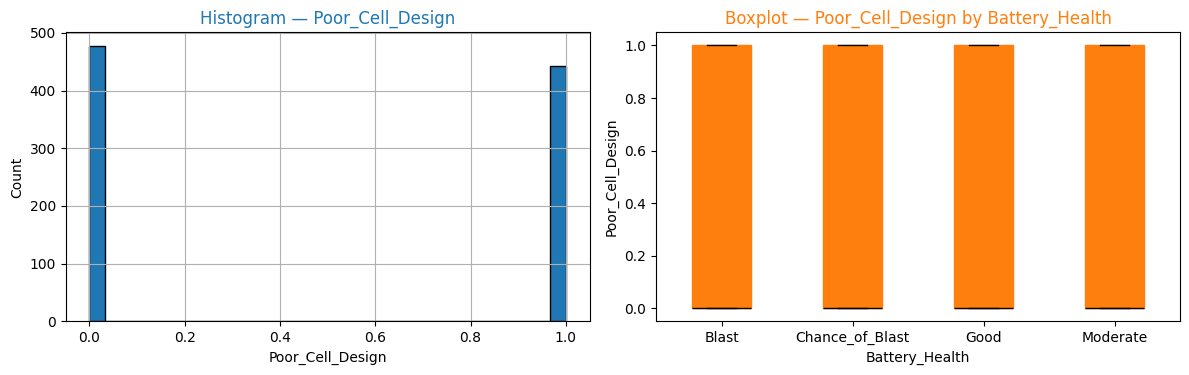

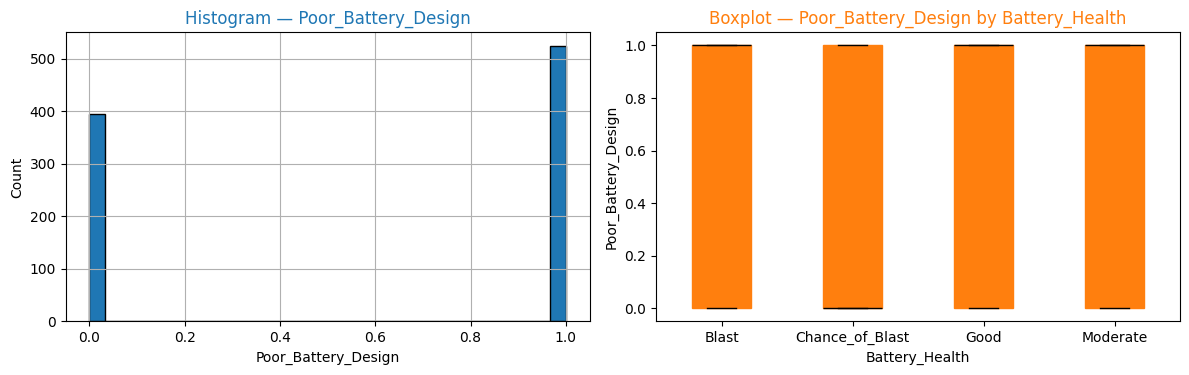

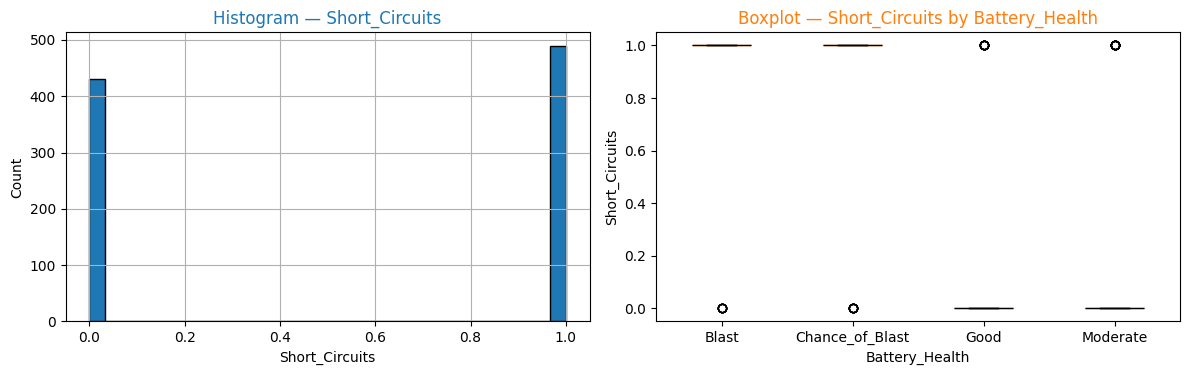

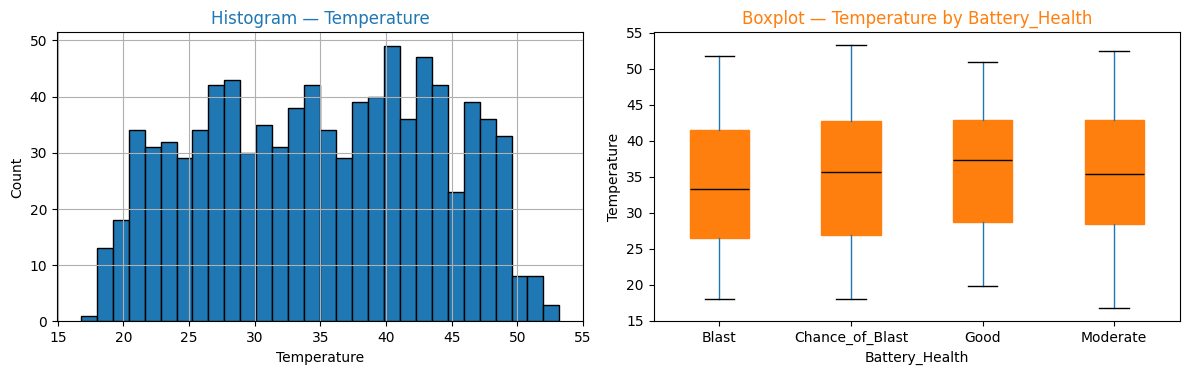

In [5]:
# ▶️ Cell 5: Exploratory Visualizations
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in df.columns if c not in numeric_cols]

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

for col in numeric_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))  # 1 row, 2 columns

    # Histograms
    df[col].hist(bins=30, edgecolor='black', color='#1f77b4', ax=axes[0])
    axes[0].set_title(f'Histogram — {col}', color='#1f77b4')
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Count')

    # Boxplot (grouped by target if possible)
    if TARGET_COLUMN in df.columns and (df[TARGET_COLUMN].dtype == 'O' or df[TARGET_COLUMN].nunique() < 30):
        df.boxplot(column=col, by=TARGET_COLUMN, grid=False, ax=axes[1],
                   patch_artist=True, boxprops=dict(facecolor='#ff7f0e', color='#ff7f0e'),
                   medianprops=dict(color='black'))
        axes[1].set_title(f'Boxplot — {col} by {TARGET_COLUMN}', color='#ff7f0e')
        axes[1].set_xlabel(TARGET_COLUMN)
    else:
        df.boxplot(column=col, grid=False, ax=axes[1],
                   patch_artist=True, boxprops=dict(facecolor='#ff7f0e', color='#ff7f0e'),
                   medianprops=dict(color='black'))
        axes[1].set_title(f'Boxplot — {col}', color='#ff7f0e')
    axes[1].set_ylabel(col)

    plt.suptitle("")  # removes default boxplot title
    plt.tight_layout()
    plt.show()


In [6]:
# ▶️ Cell 6: Train/Validation Split + Preprocessing
X = df.drop(columns=[TARGET_COLUMN])
y = df[TARGET_COLUMN]

if pd.api.types.is_numeric_dtype(y) and y.nunique() > 30:
    print("⚠️ Detected numeric target with many unique values — this looks like regression,")
    print("but this notebook runs classifiers. Consider changing TARGET_COLUMN in Cell 2.")

stratify = y if y.nunique() > 1 and y.value_counts().min() >= 2 else None

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=stratify
)

numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = [c for c in X_train.columns if c not in numeric_features]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler(with_mean=False))
])

# ✅ Handle sklearn version compatibility (sparse vs sparse_output)
try:
    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
    ])
except TypeError:
    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse=True))
    ])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop"
)

print("Split complete. Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("Target classes:", sorted(pd.Series(y_train).unique())[:10], "...")


Split complete. Train shape: (735, 8) Test shape: (184, 8)
Target classes: ['Blast', 'Chance_of_Blast', 'Good', 'Moderate'] ...


In [7]:

# ▶️ Cell 7: Helper — train, evaluate, visualize
def train_evaluate_model(name, model):
    pipe = Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="macro", zero_division=0)
    rec = recall_score(y_test, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)

    print(f"\n=== {name} ===")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")

    # Confusion Matrix
    try:
        cm = confusion_matrix(y_test, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        plt.figure()
        disp.plot(values_format='d', cmap='Blues', colorbar=False)
        plt.title(f'Confusion Matrix — {name}')
        plt.show()
    except Exception as e:
        print("Confusion matrix error:", e)

    # Classification Report
    try:
        print("\nClassification Report:")
        print(classification_report(y_test, y_pred, zero_division=0))
    except Exception as e:
        print("Classification report error:", e)

    return {
        "model": name,
        "accuracy": acc,
        "precision_macro": prec,
        "recall_macro": rec,
        "f1_macro": f1,
        "pipeline": pipe
    }

results = []



=== Decision Tree ===
Accuracy : 0.8641
Precision: 0.8637
Recall   : 0.8723
F1-score : 0.8666


<Figure size 640x480 with 0 Axes>

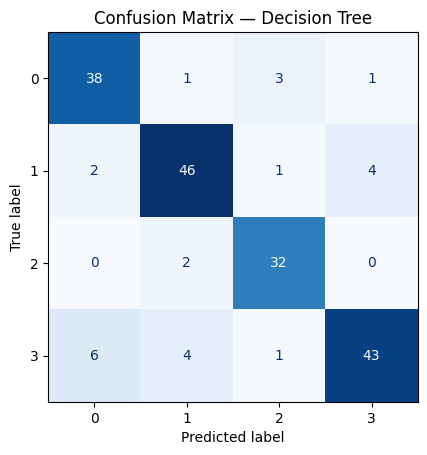


Classification Report:
                 precision    recall  f1-score   support

          Blast       0.83      0.88      0.85        43
Chance_of_Blast       0.87      0.87      0.87        53
           Good       0.86      0.94      0.90        34
       Moderate       0.90      0.80      0.84        54

       accuracy                           0.86       184
      macro avg       0.86      0.87      0.87       184
   weighted avg       0.87      0.86      0.86       184



In [8]:

# ▶️ Cell 8: Decision Tree Classifier
dt = DecisionTreeClassifier(
    random_state=RANDOM_STATE,
    class_weight="balanced",
    max_depth=None,
)
res_dt = train_evaluate_model("Decision Tree", dt)
results.append({k: v for k, v in res_dt.items() if k != "pipeline"})



=== Random Forest ===
Accuracy : 0.9076
Precision: 0.9108
Recall   : 0.9114
F1-score : 0.9103


<Figure size 640x480 with 0 Axes>

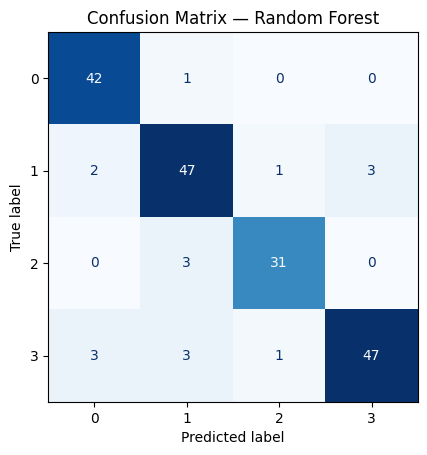


Classification Report:
                 precision    recall  f1-score   support

          Blast       0.89      0.98      0.93        43
Chance_of_Blast       0.87      0.89      0.88        53
           Good       0.94      0.91      0.93        34
       Moderate       0.94      0.87      0.90        54

       accuracy                           0.91       184
      macro avg       0.91      0.91      0.91       184
   weighted avg       0.91      0.91      0.91       184



In [9]:

# ▶️ Cell 9: Random Forest Classifier
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    class_weight="balanced_subsample",
    n_jobs=-1
)
res_rf = train_evaluate_model("Random Forest", rf)
results.append({k: v for k, v in res_rf.items() if k != "pipeline"})



=== Logistic Regression ===
Accuracy : 0.9348
Precision: 0.9358
Recall   : 0.9386
F1-score : 0.9366


<Figure size 640x480 with 0 Axes>

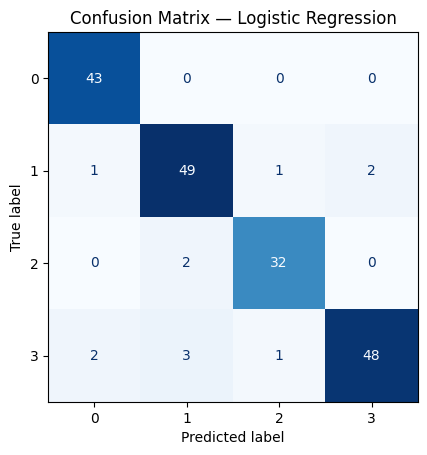


Classification Report:
                 precision    recall  f1-score   support

          Blast       0.93      1.00      0.97        43
Chance_of_Blast       0.91      0.92      0.92        53
           Good       0.94      0.94      0.94        34
       Moderate       0.96      0.89      0.92        54

       accuracy                           0.93       184
      macro avg       0.94      0.94      0.94       184
   weighted avg       0.94      0.93      0.93       184



In [10]:

# ▶️ Cell 10: Logistic Regression (One-vs-Rest)
logreg = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    n_jobs=-1
)
res_lr = train_evaluate_model("Logistic Regression", logreg)
results.append({k: v for k, v in res_lr.items() if k != "pipeline"})



=== SVM (RBF) ===
Accuracy : 0.9348
Precision: 0.9358
Recall   : 0.9386
F1-score : 0.9366


<Figure size 640x480 with 0 Axes>

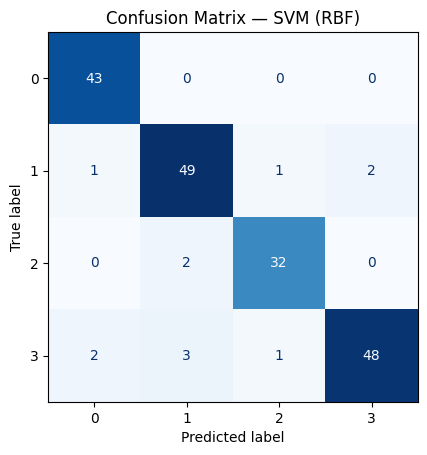


Classification Report:
                 precision    recall  f1-score   support

          Blast       0.93      1.00      0.97        43
Chance_of_Blast       0.91      0.92      0.92        53
           Good       0.94      0.94      0.94        34
       Moderate       0.96      0.89      0.92        54

       accuracy                           0.93       184
      macro avg       0.94      0.94      0.94       184
   weighted avg       0.94      0.93      0.93       184



In [11]:

# ▶️ Cell 11: Support Vector Machine (SVC)
svm = SVC(
    kernel="rbf",
    class_weight="balanced",
    probability=False
)
res_svm = train_evaluate_model("SVM (RBF)", svm)
results.append({k: v for k, v in res_svm.items() if k != "pipeline"})



=== XGBoost ===
Accuracy : 0.9185
Precision: 0.9207
Recall   : 0.9246
F1-score : 0.9218


<Figure size 640x480 with 0 Axes>

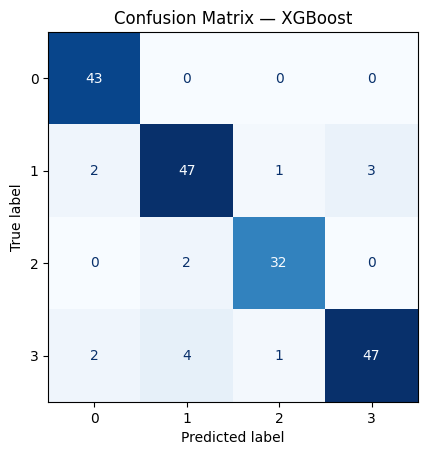


Classification Report:
                 precision    recall  f1-score   support

          Blast       0.91      1.00      0.96        43
Chance_of_Blast       0.89      0.89      0.89        53
           Good       0.94      0.94      0.94        34
       Moderate       0.94      0.87      0.90        54

       accuracy                           0.92       184
      macro avg       0.92      0.92      0.92       184
   weighted avg       0.92      0.92      0.92       184



In [12]:
# ▶️ Cell 12: XGBoost Classifier
from sklearn.preprocessing import LabelEncoder

# Encode labels into numeric (0,1,2,...)
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

xgb = XGBClassifier(
    objective="multi:softmax" if len(np.unique(y_train_enc)) > 2 else "binary:logistic",
    eval_metric="mlogloss",
    tree_method="hist",
    learning_rate=0.1,
    n_estimators=400,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=RANDOM_STATE
)

pipe = Pipeline(steps=[("preprocessor", preprocessor), ("model", xgb)])
pipe.fit(X_train, y_train_enc)
y_pred_enc = pipe.predict(X_test)

# Decode back to original labels
y_pred = le.inverse_transform(y_pred_enc)

# Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average="macro", zero_division=0)
rec = recall_score(y_test, y_pred, average="macro", zero_division=0)
f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)

print(f"\n=== XGBoost ===")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
plt.figure()
disp.plot(values_format='d', cmap='Blues', colorbar=False)
plt.title('Confusion Matrix — XGBoost')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

# Save results
res_xgb = {
    "model": "XGBoost",
    "accuracy": acc,
    "precision_macro": prec,
    "recall_macro": rec,
    "f1_macro": f1,
    "pipeline": pipe
}
results.append({k: v for k, v in res_xgb.items() if k != "pipeline"})


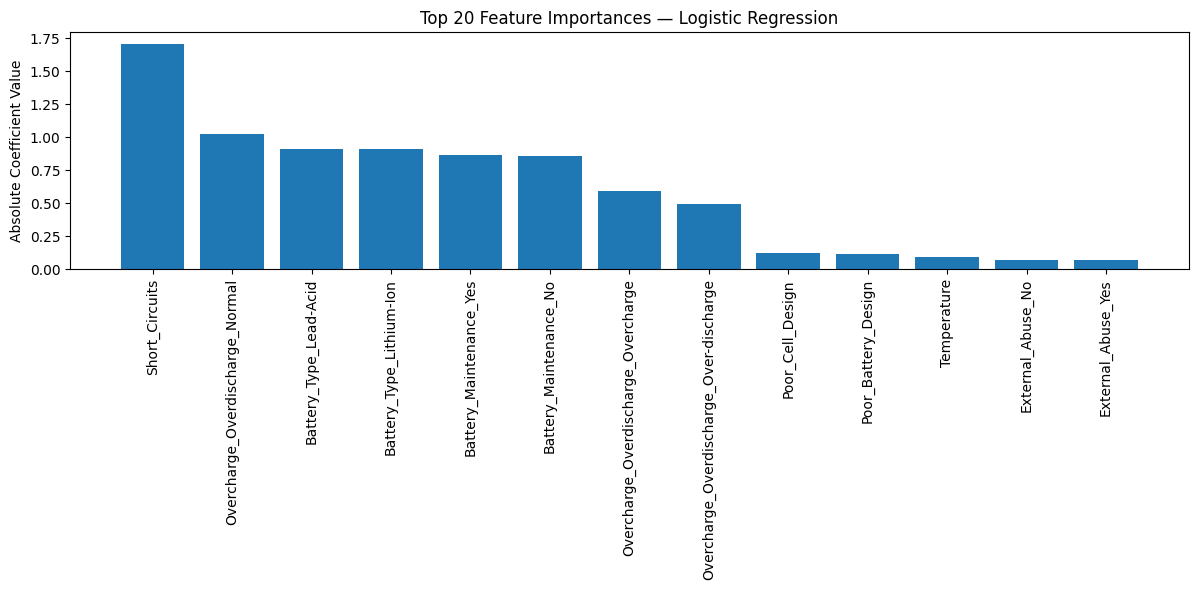

In [13]:
# ▶️ Cell 13: Feature Importance — Logistic Regression Only
import numpy as np
import matplotlib.pyplot as plt

# Helper to get feature names after preprocessing
def get_feature_names(preprocessor):
    output_features = []
    for name, trans, cols in preprocessor.transformers_:
        if name == 'num':
            output_features.extend(cols)
        elif name == 'cat':
            try:
                # for sklearn >= 1.0
                ohe = trans.named_steps['onehot']
                output_features.extend(ohe.get_feature_names_out(cols))
            except:
                # for older sklearn
                output_features.extend(trans.named_steps['onehot'].get_feature_names(cols))
    return output_features

feature_names = get_feature_names(preprocessor)

# Extract Logistic Regression model
lr_model = res_lr['pipeline'].named_steps['model']

# Compute feature importance as absolute value of coefficients
if hasattr(lr_model, "coef_"):
    importances = np.mean(np.abs(lr_model.coef_), axis=0)  # average across classes
else:
    raise ValueError("Logistic Regression model has no coef_ attribute.")

# Plot top 20 features
top_n = 20
sorted_idx = np.argsort(importances)[::-1][:top_n]

plt.figure(figsize=(12,6))
plt.bar(range(len(sorted_idx)), importances[sorted_idx], align='center')
plt.xticks(range(len(sorted_idx)), np.array(feature_names)[sorted_idx], rotation=90)
plt.title("Top 20 Feature Importances — Logistic Regression")
plt.ylabel("Absolute Coefficient Value")
plt.tight_layout()
plt.show()


,model,accuracy,precision_macro,recall_macro,f1_macro
0,Logistic Regression,0.934783,0.935842,0.938648,0.936608
1,SVM (RBF),0.934783,0.935842,0.938648,0.936608
2,XGBoost,0.918478,0.920716,0.924585,0.921843
3,Random Forest,0.907609,0.910845,0.911418,0.910264
4,Decision Tree,0.864130,0.863677,0.872280,0.866601



🏆 Best model: Logistic Regression
model              Logistic Regression
accuracy                      0.934783
precision_macro               0.935842
recall_macro                  0.938648
f1_macro                      0.936608
Name: 2, dtype: object


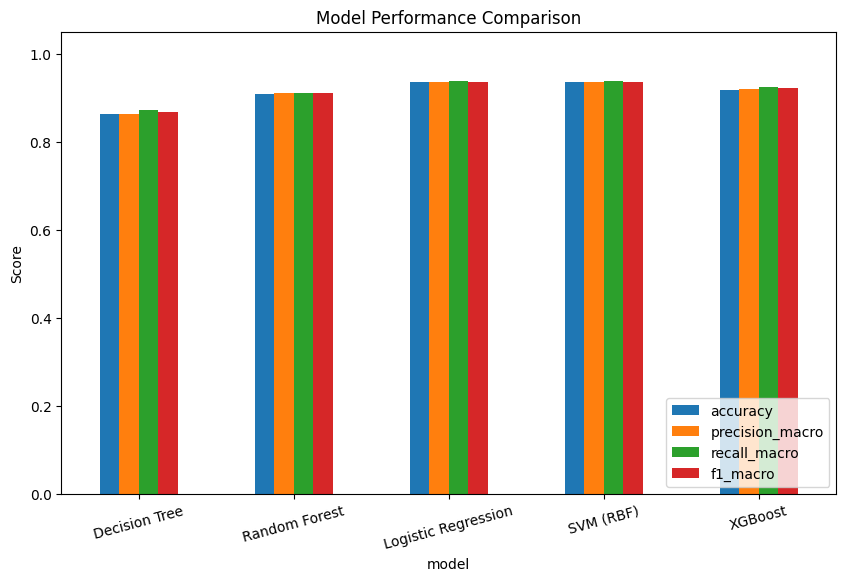

In [18]:

# ▶️ Cell 14: Compare Models & Pick Best
results_df = pd.DataFrame(results)
display(results_df.sort_values("f1_macro", ascending=False).reset_index(drop=True))

# Best by F1 (macro); tie-breaker by accuracy
best = results_df.sort_values(["f1_macro", "accuracy"], ascending=False).iloc[0]
print("\n🏆 Best model:", best["model"])
print(best)

# Bar plot of metrics
ax = results_df.set_index("model")[["accuracy","precision_macro","recall_macro","f1_macro"]].plot(kind="bar", figsize=(10,6), rot=15)
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.legend(loc="lower right")
plt.show()


In [19]:
# ▶️ Cell 15: Predict Batteries That Can Blast Using Best Model

# 1️⃣ Find the best model from results
best_model_name = results_df.sort_values(["f1_macro", "accuracy"], ascending=False).iloc[0]["model"]
print(f"Model selected for prediction: {best_model_name}")

# 2️⃣ Map best model name to its trained pipeline
model_map = {
    "Decision Tree": res_dt['pipeline'],
    "Random Forest": res_rf['pipeline'],
    "Logistic Regression": res_lr['pipeline'],
    "SVM (RBF)": res_svm['pipeline'],
    "XGBoost": res_xgb['pipeline']
}

best_pipeline = model_map[best_model_name]

# 3️⃣ Predict for the entire dataset
y_pred_all = best_pipeline.predict(X)

# 4️⃣ Add predictions to the original dataframe
df_pred = df.copy()
df_pred['Predicted_Status'] = y_pred_all

# 5️⃣ Filter batteries predicted as risky
risky_labels = ["Blast", "Chance_of_Blast"]  # categories considered at risk
batteries_to_blast = df_pred[df_pred['Predicted_Status'].isin(risky_labels)]

print(f"⚠️ Number of batteries predicted to blast: {len(batteries_to_blast)}")
display(batteries_to_blast)


Model selected for prediction: Logistic Regression
⚠️ Number of batteries predicted to blast: 489


,Battery_Type,Poor_Cell_Design,External_Abuse,Poor_Battery_Design,Short_Circuits,Temperature,Overcharge_Overdischarge,Battery_Maintenance,Battery_Health,Predicted_Status
3,Lead-Acid,0,No,0,1,33.731964,Over-discharge,Yes,Blast,Blast
4,Lead-Acid,1,Yes,1,1,44.063272,Over-discharge,No,Blast,Blast
6,Lead-Acid,1,No,1,1,42.500575,Normal,Yes,Blast,Blast
8,Lithium-Ion,1,Yes,0,1,37.309658,Over-discharge,Yes,Chance_of_Blast,Chance_of_Blast
10,Lead-Acid,1,Yes,1,1,37.213997,Normal,Yes,Blast,Blast
...,...,...,...,...,...,...,...,...,...,...
913,Lead-Acid,1,Yes,0,1,33.041477,Normal,Yes,Blast,Blast
914,Lead-Acid,0,Yes,1,1,32.317383,Normal,No,Blast,Blast
915,Lead-Acid,1,Yes,0,1,39.248103,Over-discharge,Yes,Blast,Blast
917,Lithium-Ion,1,No,0,1,25.002202,Overcharge,No,Chance_of_Blast,Chance_of_Blast
